In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#df = pd.read_excel('results/metrics_data.xlsx',"EnergyTimeSeries")
df = pd.read_csv('results/metrics_data_5min.csv')

<Axes: xlabel='StepIndex', ylabel='Energy (Joules)'>

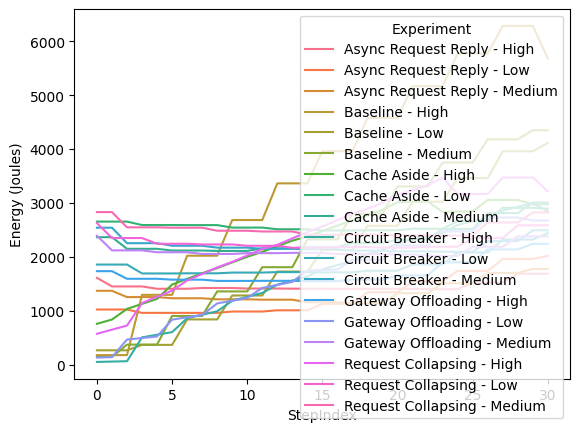

In [3]:
df2 = df.groupby(["Pattern","Workload","StepIndex"])["Energy (Joules)"].mean().reset_index()
df2["Experiment"] = df2["Pattern"] + " - " + df2["Workload"]
sns.lineplot(
    data=df2.groupby(["Experiment","StepIndex"])["Energy (Joules)"].sum().reset_index(),
    x="StepIndex",             # or use "StepIndex" for simpler x-axis
    y="Energy (Joules)",
    hue="Experiment",               # one line per RunID
    estimator=None             # plot raw values instead of mean
)

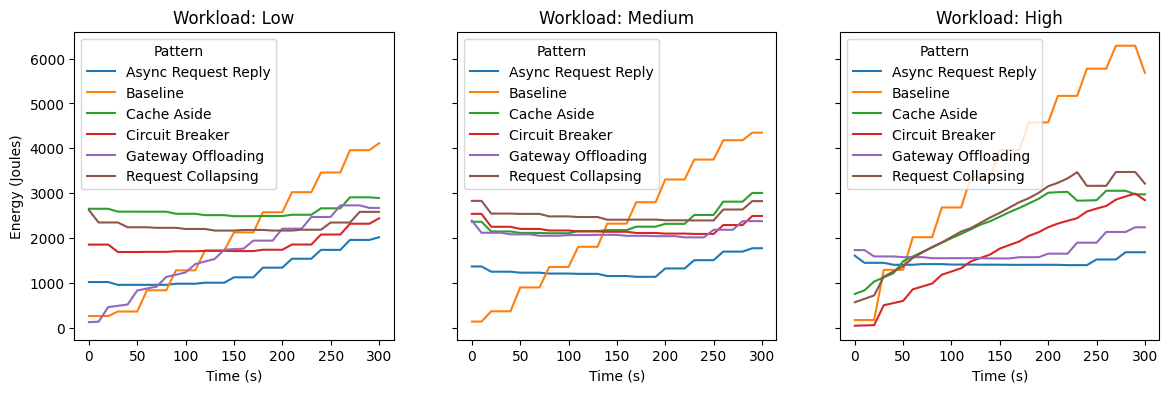

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
ax = {"Low": 0,
    "Medium": 1,
    "High": 2}
data_df = df.rename(columns={"StepIndex": "Time (s)"})
data_df["Time (s)"] = data_df["Time (s)"] * 10
for workload, group in data_df.groupby("Workload"):
    sns.lineplot(
        data=group.groupby(["Pattern", "Time (s)"])["Energy (Joules)"].mean().reset_index().sort_values("Pattern"),
        x="Time (s)",
        y="Energy (Joules)",
        hue="Pattern",
        ax=axes[ax[workload]],
        estimator=None,
        legend=True
    )
    axes[ax[workload]].set_title(f"Workload: {workload}")


#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05))


In [39]:
fig.savefig("results/plots/energy-pipeline_plot.eps", dpi=300, bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [40]:
from pandas.api.types import CategoricalDtype
order = CategoricalDtype(['Low', 'Medium', 'High'], ordered=True)

In [ ]:
df_energy = pd.read_csv("results/energy_mesurements_data_5min.csv")
df_energy["Workload Level"] = df_energy["Workload Level"].astype(order)
df_energy.sort_values(by=["Pattern", "Workload Level"], inplace=True)
df_energy["ER"] = df_energy["EC"] / df_energy["TotalRequests"]

In [50]:
def abbreviate_number(n):
    if pd.isna(n):
        return n
    elif abs(n) >= 1_000_000_000:
        return f"{n / 1_000_000_000:.1f}B"
    elif abs(n) >= 1_000_000:
        return f"{n / 1_000_000:.1f}M"
    elif abs(n) >= 1_000:
        return f"{n / 1_000:.1f}K"
    else:
        return f"{n:.1f}"

In [51]:
df_energy[[c for c in df_energy.columns if c not in ["Pattern", "Workload Level", "Timestamp"]]] = df_energy[[c for c in df_energy.columns if c not in ["Pattern", "Workload Level", "Timestamp"]]].map(abbreviate_number)
df_energy = df_energy[df_energy["Workload Level"] == "High"]
df_energy = df_energy[df_energy["Pattern"].isin(["Baseline", "Cache Aside", "Request Collapsing"])]
df_energy = df_energy[["Pattern", "Workload Level", "Timestamp"] + [c for c in df_energy.columns if c not in ["Pattern", "Workload Level", "Timestamp"]]]
df_energy[[c for c in df_energy.columns if c not in ["Timestamp"]]].to_csv("results/energy_measurements_5min_abbreviated.csv", index=False)